<a href="https://colab.research.google.com/github/ithelga/beeline-banner-ab-test/blob/dev/notebooks/Team1_HW5_CDA_i2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SmartAds Efficiency**: Оптимизация эффективности маркетинговых каналов

## [STAGE 4_2] **Проведение подтверждающего анализ (СDA) - 2-ая итерация**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import os
import warnings
import polars as pl
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, proportion_effectsize
from statsmodels.stats.contingency_tables import Table2x2
from scipy.stats import fisher_exact, norm
from statsmodels.stats.power import NormalIndPower

warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

colors = ["#282828", "#F5C341", "#FFDB7D", "#F0F0F0", "#FFFFFF"] # Основная палитра

graph_path = 'drive/MyDrive/Colab Notebooks/Beeline Banner AB-test/graph'
data_path = 'drive/MyDrive/Colab Notebooks/Beeline Banner AB-test/data'

Mounted at /content/drive


In [2]:
# Настройка визуалзаций
plt.rcParams['figure.facecolor'] = colors[3]   # фон вокруг области построения
plt.rcParams['axes.facecolor'] = colors[4]     # фон внутри графика
plt.rcParams['axes.edgecolor'] = colors[0]     # рамка графика

plt.rcParams['text.color'] = colors[0]         # общий цвет текста
plt.rcParams['axes.labelcolor'] = colors[0]    # подписи осей
plt.rcParams['xtick.color'] = colors[0]        # подписи по оси X
plt.rcParams['ytick.color'] = colors[0]        # подписи по оси Y

### Загружаем данные с Google Disk

In [3]:
supertable = pd.read_csv(f'{data_path}/supertable.csv')
supertable.head()

,user_id,timestamp,date,shows,clicks,banner_first,campaign_first,placement,device_type,os,geo,has_install_event,has_first_order_event,has_registration_event,has_tariff_switch_event,segment,tariff,creative_type,size,target_audience_segment
0,1,2025-02-10 10:06:23,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
1,1,2025-02-15 20:05:59,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
2,1,2025-02-16 08:34:35,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
3,1,2025-02-17 21:55:14,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
4,1,2025-03-01 20:13:19,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression


### Агрегируем данные

In [4]:
# ПАРАМЕТРЫ ДЛЯ ТЕСТОВ ПО ДАННЫМ SUPERTABLE

# ---------- Гипотеза 1 ----------
static_shows  = supertable.loc[supertable.creative_type == "static", "shows"].sum()
static_clicks = supertable.loc[supertable.creative_type == "static", "clicks"].sum()

animated_shows  = supertable.loc[supertable.creative_type.isin(["video", "rich"]), "shows"].sum()
animated_clicks = supertable.loc[supertable.creative_type.isin(["video", "rich"]), "clicks"].sum()


# ---------- Гипотеза 2 ----------
web_shows     = supertable.loc[supertable.os == "web", "shows"].sum()
web_clicks    = supertable.loc[supertable.os == "web", "clicks"].sum()

mobile_shows  = supertable.loc[supertable.os.isin(["android", "ios"]), "shows"].sum()
mobile_clicks = supertable.loc[supertable.os.isin(["android", "ios"]), "clicks"].sum()


# ---------- Гипотеза 3 ----------
app_shows     = supertable.loc[supertable.placement == "app", "shows"].sum()
app_switches  = supertable.loc[supertable.placement == "app", "has_tariff_switch_event"].sum()

site_shows    = supertable.loc[supertable.placement == "site", "shows"].sum()
site_switches = supertable.loc[supertable.placement == "site", "has_tariff_switch_event"].sum()

social_shows    = supertable.loc[supertable.placement == "social", "shows"].sum()
social_switches = supertable.loc[supertable.placement == "social", "has_tariff_switch_event"].sum()


# ---------- Гипотеза 4 ----------
tablet_regs  = supertable.loc[supertable.device_type == "tablet", "has_registration_event"].sum()
tablet_sw    = supertable.loc[supertable.device_type == "tablet", "has_tariff_switch_event"].sum()

phone_regs   = supertable.loc[supertable.device_type == "phone", "has_registration_event"].sum()
phone_sw     = supertable.loc[supertable.device_type == "phone", "has_tariff_switch_event"].sum()

На [первой итерации CDA](https://colab.research.google.com/drive/1_gwujcUP5RvHt9vb7MY2JzSXBXkEK50B?usp=drive_link) анализа были испробованы базовые методы:

• Классический z-test для сравнения двух долей (первичная проверка гипотез).

• Bootstrap для оценки доверительных интервалов эффекта (непараметрическая проверка).

Результаты этих методов оказались неустойчивыми, таким образом на второй итерации CDA будет использована более гибкая надстройка.

### Выбираем подходящий тест

In [5]:
class TestSelector:
    """
    Автоматический выбор статистического теста по правилам.

    Логика:
    - Fisher, если:
        * total < 50,
        * successes < 5,
        * failures < 5,
        * ИЛИ спец. случай для очень малых CTR: total < 150 и p < 0.15
    - Bonferroni при comparisons > 1
    - Иначе Z-test
    """

    def __init__(self, alpha=0.1):
        self.alpha = alpha

    def _need_fisher(self, succ, total):
        failures = total - succ
        p = succ / total if total > 0 else 0

        if total < 50 or succ < 5 or failures < 5:
            return True

        if total < 150 and p < 0.15:
            return True

        return False

    def choose_test(self, succ_a, total_a, succ_b, total_b, comparisons=1):
        if self._need_fisher(succ_a, total_a) or self._need_fisher(succ_b, total_b):
            return {
                "test": "fisher",
                "reason": (
                    "Выбран Fisher: одна из групп мала (total < 50 / successes < 5 / "
                    "failures < 5) или total < 150 при низкой конверсии (<15%)."
                )
            }

        if comparisons > 1:
            return {
                "test": "z-test + bonferroni",
                "reason": "Выбран Z-test + Bonferroni, так как comparisons > 1."
            }

        return {
            "test": "z-test",
            "reason": "Выбран Z-test — выборки достаточно большие."
        }

In [6]:
# ---------- Гипотеза 1 ----------

selector = TestSelector()

selector.choose_test(
    succ_a=animated_clicks,
    total_a=animated_shows,
    succ_b=static_clicks,
    total_b=static_shows
)


{'test': 'z-test', 'reason': 'Выбран Z-test — выборки достаточно большие.'}

In [7]:
# ---------- Гипотеза 2 ----------

selector.choose_test(
    succ_a=web_clicks,
    total_a=web_shows,
    succ_b=mobile_clicks,
    total_b=mobile_shows
)


{'test': 'fisher',
 'reason': 'Выбран Fisher: одна из групп мала (total < 50 / successes < 5 / failures < 5) или total < 150 при низкой конверсии (<15%).'}

In [8]:
# ---------- Гипотеза 3 ----------
selector.choose_test(app_switches, app_shows, site_switches, site_shows, comparisons=2)
selector.choose_test(app_switches, app_shows, social_switches, social_shows, comparisons=2)

{'test': 'z-test + bonferroni',
 'reason': 'Выбран Z-test + Bonferroni, так как comparisons > 1.'}

In [9]:
# ---------- Гипотеза 4 ----------
selector.choose_test(tablet_sw, tablet_regs, phone_sw, phone_regs)

{'test': 'z-test', 'reason': 'Выбран Z-test — выборки достаточно большие.'}

### Проверяем гипотезы

In [10]:
from scipy.stats import norm

class ZTest:
    """Z-test для сравнения двух пропорций pA > pB."""

    def run(self, succ_a, total_a, succ_b, total_b, alpha=0.1):
        p_a = succ_a / total_a
        p_b = succ_b / total_b
        lift = p_a / p_b - 1

        # Z-test (p-value не зависит от alpha)
        stat, p_value = proportions_ztest(
            [succ_a, succ_b],
            [total_a, total_b],
            alternative="larger"
        )

        # === CI для разницы долей ===
        se = np.sqrt(
            p_a * (1 - p_a) / total_a +
            p_b * (1 - p_b) / total_b
        )
        diff = p_a - p_b

        # корректное z-критическое
        z_crit = norm.ppf(1 - alpha / 2)

        diff_low = diff - z_crit * se
        diff_high = diff + z_crit * se

        ci_lift = (diff_low / p_b, diff_high / p_b)

        return {
            "method": "z-test",
            "p_value": p_value,
            "p_a": p_a,
            "p_b": p_b,
            "lift": lift,
            "ci_lift": ci_lift
        }

In [11]:
class FisherTest:
    """Fisher's Exact Test с CI для отношения шансов."""

    def run(self, succ_a, total_a, succ_b, total_b, alpha=0.1):
        table = [
            [succ_a, total_a - succ_a],
            [succ_b, total_b - succ_b]
        ]

        odds_ratio, p_value = fisher_exact(table, alternative="greater")

        p_a = succ_a / total_a
        p_b = succ_b / total_b
        lift = p_a / p_b - 1

        # === CI для OR через statsmodels ===
        try:
            table_obj = Table2x2(table)

            # statsmodels ожидает alpha для ДВУСТОРОННЕГО CI
            ci_or = table_obj.oddsratio_confint(alpha=alpha)

            ci_lift = (ci_or[0] - 1, ci_or[1] - 1)

        except:
            # === Fallback ===
            se = np.sqrt(
                p_a * (1 - p_a) / total_a +
                p_b * (1 - p_b) / total_b
            )
            diff = p_a - p_b
            z_crit = norm.ppf(1 - alpha / 2)

            diff_low = diff - z_crit * se
            diff_high = diff + z_crit * se

            ci_lift = (diff_low / p_b, diff_high / p_b)

        return {
            "method": "fisher",
            "p_value": p_value,
            "p_a": p_a,
            "p_b": p_b,
            "lift": lift,
            "ci_lift": ci_lift
        }

In [12]:
class BonferroniCorrector:
    """Коррекция p-value для нескольких сравнений."""

    @staticmethod
    def correct(p_value, comparisons):
        return min(p_value * comparisons, 1.0)

In [13]:
class HypothesisEvaluator:
    """
    Двухуровневая проверка гипотезы:
    1) Проверка статистической значимости (p-value < alpha)
    2) Проверка бизнес-порога (нижняя граница CI лифта >= threshold)
    """

    def __init__(self, alpha=0.1):
        self.alpha = alpha

    def evaluate(self, test_class, succ_a, total_a, succ_b, total_b,
                 threshold=None, comparisons=1, name_a="Группа A", name_b="Группа B"):

        # Выполняем статистический тест
        results = test_class.run(succ_a, total_a, succ_b, total_b, alpha=self.alpha)

        method = results["method"]
        p_value = results["p_value"]

        # Коррекция Bonferroni для множественных сравнений
        if comparisons > 1:
            p_value_corrected = BonferroniCorrector.correct(p_value, comparisons)
        else:
            p_value_corrected = p_value

        # Уровень A — статистическая значимость
        effect_exists = p_value_corrected < self.alpha

        # Уровень B — бизнес-порог
        if threshold is not None and results["ci_lift"] is not None:
            ci_low, ci_high = results["ci_lift"]
            meets_threshold = ci_low >= threshold
        else:
            meets_threshold = None
            ci_low = ci_high = None

        # Формируем отчет
        summary = []
        summary.append(f"Проверка гипотезы: сравнение {name_a} и {name_b}")
        summary.append(f"Метод тестирования: {method}\n")

        # Фактические показатели
        summary.append("Фактические показатели:")
        summary.append(f"- Конверсия {name_a}: {results['p_a']*100:.2f}%")
        summary.append(f"- Конверсия {name_b}: {results['p_b']*100:.2f}%")
        summary.append(f"- Относительная разница (lift): {results['lift']*100:.2f}%\n")

        # Проверка статистической значимости
        summary.append("Проверка статистической значимости:")
        summary.append(f"- p-value = {p_value_corrected:.5f} (alpha = {self.alpha})")
        if effect_exists:
            summary.append("- Различие статистически значимо.\n")
        else:
            summary.append("- Статистически значимого различия не выявлено.\n")

        # Доверительный интервал для лифта
        if results["ci_lift"] is not None:
            low, high = results["ci_lift"]
            summary.append("Доверительный интервал относительного эффекта (90%):")
            summary.append(f"- от {low*100:.2f}% до {high*100:.2f}%\n")

        # Проверка бизнес-порога
        if threshold is not None and results["ci_lift"] is not None:
            threshold_pct = threshold * 100
            summary.append(f"Проверка бизнес-порога ({threshold_pct:.0f}%):")
            summary.append(f"- Нижняя граница CI: {low*100:.2f}%")
            if meets_threshold:
                summary.append("- Эффект достигает заданного порога.\n")
            else:
                summary.append("- Эффект не достигает заданного порога.\n")

        # Итоговое решение - 4 исхода

        if effect_exists and meets_threshold:
            summary.append("Итоговое решение: гипотеза подтверждается.")
            summary.append(f"Статистически значимый эффект и превышение бизнес-порога ({threshold_pct:.0f}%).")

        elif effect_exists and not meets_threshold:
            summary.append("Итоговое решение: гипотеза частично подтверждена.")
            summary.append(f"Есть статистически значимый эффект (p = {p_value_corrected:.4f}),")
            summary.append(f"но бизнес-порог {threshold_pct:.0f}% не достигнут (нижняя граница CI: {low*100:.2f}%).")

        elif not effect_exists and meets_threshold:
            summary.append("Итоговое решение: результат неоднозначный.")
            summary.append("Нижняя граница доверительного интервала превышает бизнес-порог,")
            summary.append(f"но статистическая значимость отсутствует (p = {p_value_corrected:.4f}).")
            summary.append("Рекомендация: собрать больше данных для повышения мощности анализа.")

        else:
            summary.append("Итоговое решение: гипотеза не подтверждается.")
            if not effect_exists and meets_threshold is False:
                summary.append(f"Нет статистической значимости (p = {p_value_corrected:.4f}), "
                              f"и нижняя граница доверительного интервала ({low*100:.2f}%) "
                              f"ниже порога {threshold_pct:.0f}%.")
            elif not effect_exists:
                summary.append(f"Нет статистической значимости (p = {p_value_corrected:.4f}).")
            elif meets_threshold is False:
                summary.append(f"Нижняя граница доверительного интервала ({low*100:.2f}%) "
                              f"ниже порога {threshold_pct:.0f}%.")


        summary_text = "\n".join(summary)

        return {
            **results,
            "p_value_corrected": p_value_corrected,
            "effect_exists": effect_exists,
            "meets_threshold": meets_threshold,
            "summary": summary_text
        }

#### Проверяем гипотезу 1

> Показ анимированного баннера дает CTR более чем на 25% выше по сравнению со статичным баннером.

In [14]:
test = ZTest()
evaluator = HypothesisEvaluator()

result = evaluator.evaluate(
    test_class=test,
    succ_a=animated_clicks,
    total_a=animated_shows,
    succ_b=static_clicks,
    total_b=static_shows,
    threshold=0.25,
    name_a="Анимированные",
    name_b="Статичные"
)

print(result["summary"])

Проверка гипотезы: сравнение Анимированные и Статичные
Метод тестирования: z-test

Фактические показатели:
- Конверсия Анимированные: 9.63%
- Конверсия Статичные: 7.80%
- Относительная разница (lift): 23.43%

Проверка статистической значимости:
- p-value = 0.08350 (alpha = 0.1)
- Различие статистически значимо.

Доверительный интервал относительного эффекта (90%):
- от -4.64% до 51.51%

Проверка бизнес-порога (25%):
- Нижняя граница CI: -4.64%
- Эффект не достигает заданного порога.

Итоговое решение: гипотеза частично подтверждена.
Есть статистически значимый эффект (p = 0.0835),
но бизнес-порог 25% не достигнут (нижняя граница CI: -4.64%).


#### Проверяем гипотезу 2

> Пользователи веб-версии не менее, чем на 30% чаще кликают на рекламу (CTR), чем пользователи мобильного приложения

In [15]:
# создаём нужный тест
test = FisherTest()

# проверяем гипотезу
evaluator = HypothesisEvaluator()

result_h2 = evaluator.evaluate(
    test,
    succ_a=web_clicks, total_a=web_shows,
    succ_b=mobile_clicks, total_b=mobile_shows,
    threshold=0.30,
    name_a="WEB",
    name_b="MOBILE"
)

print(result_h2["summary"])

Проверка гипотезы: сравнение WEB и MOBILE
Метод тестирования: fisher

Фактические показатели:
- Конверсия WEB: 11.36%
- Конверсия MOBILE: 8.44%
- Относительная разница (lift): 34.68%

Проверка статистической значимости:
- p-value = 0.16019 (alpha = 0.1)
- Статистически значимого различия не выявлено.

Доверительный интервал относительного эффекта (90%):
- от -13.36% до 123.41%

Проверка бизнес-порога (30%):
- Нижняя граница CI: -13.36%
- Эффект не достигает заданного порога.

Итоговое решение: гипотеза не подтверждается.
Нет статистической значимости (p = 0.1602).


#### Проверяем гипотезу 3

> Размещение рекламы в приложении увеличивает вероятность смены тарифа не менее чем на 25% по сравнению с сайтом/соц сетями

**APP > SITE**

In [16]:
test_site = ZTest()

evaluator = HypothesisEvaluator()

result_h3_site = evaluator.evaluate(
    test_site,
    succ_a=app_switches, total_a=app_shows,
    succ_b=site_switches, total_b=site_shows,
    threshold=0.25,
    comparisons=2,
    name_a="APP",
    name_b="SITE"
)

print(result_h3_site["summary"])

Проверка гипотезы: сравнение APP и SITE
Метод тестирования: z-test

Фактические показатели:
- Конверсия APP: 14.14%
- Конверсия SITE: 10.89%
- Относительная разница (lift): 29.86%

Проверка статистической значимости:
- p-value = 0.06342 (alpha = 0.1)
- Различие статистически значимо.

Доверительный интервал относительного эффекта (90%):
- от 3.30% до 56.43%

Проверка бизнес-порога (25%):
- Нижняя граница CI: 3.30%
- Эффект не достигает заданного порога.

Итоговое решение: гипотеза частично подтверждена.
Есть статистически значимый эффект (p = 0.0634),
но бизнес-порог 25% не достигнут (нижняя граница CI: 3.30%).


**APP > SOCIAL**

In [17]:
test_social = ZTest()

result_h3_social = evaluator.evaluate(
    test_social,
    succ_a=app_switches, total_a=app_shows,
    succ_b=social_switches, total_b=social_shows,
    threshold=0.25,
    comparisons=2,
    name_a="APP",
    name_b="SOCIAL"
)

print(result_h3_social["summary"])

Проверка гипотезы: сравнение APP и SOCIAL
Метод тестирования: z-test

Фактические показатели:
- Конверсия APP: 14.14%
- Конверсия SOCIAL: 11.22%
- Относительная разница (lift): 25.96%

Проверка статистической значимости:
- p-value = 0.17296 (alpha = 0.1)
- Статистически значимого различия не выявлено.

Доверительный интервал относительного эффекта (90%):
- от -4.53% до 56.45%

Проверка бизнес-порога (25%):
- Нижняя граница CI: -4.53%
- Эффект не достигает заданного порога.

Итоговое решение: гипотеза не подтверждается.
Нет статистической значимости (p = 0.1730).


Гипотеза не подтверждается, нет статистической значимости по APP и SOCIAL, и эффект в парах APP & SOCIAL и APP & SITE ниже порога.

#### Проверяем гипотезу 4

> Просмотр рекламы на устройстве tablet увеличивает вероятность смены тарифа более, чем на 10 %  по сравнению с другими устройствами после регистрации пользователей

In [18]:
test = ZTest()

evaluator = HypothesisEvaluator()

result_h4 = evaluator.evaluate(
    test,
    succ_a=tablet_sw, total_a=tablet_regs,
    succ_b=phone_sw,  total_b=phone_regs,
    threshold=0.10,
    name_a="TABLET",
    name_b="PHONE"
)

print(result_h4["summary"])

Проверка гипотезы: сравнение TABLET и PHONE
Метод тестирования: z-test

Фактические показатели:
- Конверсия TABLET: 30.08%
- Конверсия PHONE: 26.94%
- Относительная разница (lift): 11.66%

Проверка статистической значимости:
- p-value = 0.23610 (alpha = 0.1)
- Статистически значимого различия не выявлено.

Доверительный интервал относительного эффекта (90%):
- от -15.63% до 38.95%

Проверка бизнес-порога (10%):
- Нижняя граница CI: -15.63%
- Эффект не достигает заданного порога.

Итоговое решение: гипотеза не подтверждается.
Нет статистической значимости (p = 0.2361).


### Анализируем мощность

In [19]:
class PowerAnalyzer:
    """
    Анализ мощности тестов (power analysis).
    """

    def __init__(self, alpha=0.1, power_target=0.8):
        self.alpha = alpha
        self.power_target = power_target
        self.power_calc = NormalIndPower()

        # ЯВНО используем твою палитру
        self.COLORS = {
            "text": colors[0],
            "accent": colors[1],
            "secondary": colors[2],
            "hist": colors[2],
            "line": colors[1],
            "target": colors[0],
            "grid": "#DDDDDD"
        }

    def compute_power(self, p1, p2, n1, n2):
        effect = proportion_effectsize(p1, p2)
        return self.power_calc.power(
            effect,
            nobs1=n1,
            ratio=n2 / n1,
            alpha=self.alpha
        )

    def required_sample(self, p1, p2):
        effect = proportion_effectsize(p1, p2)
        return self.power_calc.solve_power(
            effect,
            power=self.power_target,
            alpha=self.alpha
        )

    def bootstrap_lift(self, succ_a, total_a, succ_b, total_b, n_boot=5000):
        p_a = succ_a / total_a
        p_b = succ_b / total_b

        lifts = []
        for _ in range(n_boot):
            clicks_a = np.random.binomial(total_a, p_a)
            clicks_b = np.random.binomial(total_b, p_b)

            ctr_a = clicks_a / total_a
            ctr_b = clicks_b / total_b

            lift = (ctr_a - ctr_b) / ctr_b
            lifts.append(lift)

        return np.array(lifts)

    def plot_pair(self, lifts, p1, p2, name_a, name_b, max_n=6000):

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # ===== Bootstrap =====
        axes[0].hist(
            lifts,
            bins=40,
            color=self.COLORS["hist"],
            edgecolor=self.COLORS["text"],
            alpha=0.8
        )

        axes[0].axvline(
            np.mean(lifts),
            color=self.COLORS["accent"],
            linewidth=2,
            label="Средний лифт"
        )

        axes[0].set_title(
            f"Bootstrap лифта: {name_a} vs {name_b}",
            fontweight="bold"
        )
        axes[0].set_xlabel("Лифт")
        axes[0].set_ylabel("Частота")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        # ===== Power Curve =====
        ns = np.arange(100, max_n, 200)
        effect = proportion_effectsize(p1, p2)

        powers = [
            self.power_calc.power(
                effect,
                nobs1=n,
                ratio=1.0,
                alpha=self.alpha
            )
            for n in ns
        ]

        axes[1].plot(
            ns,
            powers,
            color=self.COLORS["line"],
            linewidth=2,
            label="Мощность"
        )

        axes[1].axhline(
            self.power_target,
            color=self.COLORS["target"],
            linestyle="--",
            linewidth=2,
            label=f"{int(self.power_target * 100)}% мощность"
        )

        axes[1].set_title(
            f"Power Curve: {name_a} vs {name_b}",
            fontweight="bold"
        )
        axes[1].set_xlabel("Размер выборки в группе")
        axes[1].set_ylabel("Мощность теста")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        plt.tight_layout()

        # ===== Сохранение =====
        os.makedirs(graph_path, exist_ok=True)

        filename = f"power_analysis_{name_a}_vs_{name_b}".lower().replace(" ", "_")
        filepath = os.path.join(graph_path, f"{filename}.png")

        plt.savefig(
            filepath,
            dpi=150,
            bbox_inches="tight",
            facecolor=plt.gcf().get_facecolor()
        )

        plt.show()

    def analyze(self, succ_a, total_a, succ_b, total_b, name_a="A", name_b="B"):

        p_a = succ_a / total_a
        p_b = succ_b / total_b

        # Мощность
        power = self.compute_power(p_b, p_a, total_b, total_a)

        # Требуемый размер
        try:
            required_n = self.required_sample(p_a, p_b)
        except Exception:
            required_n = None

        # Bootstrap
        lifts = self.bootstrap_lift(
            succ_a,
            total_a,
            succ_b,
            total_b
        )

        # Графики
        self.plot_pair(lifts, p_a, p_b, name_a, name_b)

        # Вывод
        print("\n==============================")
        print(f" АНАЛИЗ МОЩНОСТИ: {name_a} vs {name_b}")
        print("==============================")

        print(f"Текущий размер выборки: {name_a} = {total_a}, {name_b} = {total_b}")

        if required_n:
            print(f"Необходимый размер выборки: {required_n:.0f} на группу")
        else:
            print("Необходимый размер выборки: невозможно оценить.")

        print(f"\nТекущая мощность теста: {power:.3f}")
        print(f"Целевая мощность: {self.power_target}")

        print("\nBootstrap лифт:")
        print(f"- средний: {np.mean(lifts) * 100:.2f}%")
        print(
            f"- 90% CI: "
            f"{np.percentile(lifts, 2.5) * 100:.2f}%, "
            f"{np.percentile(lifts, 97.5) * 100:.2f}%"
        )

        return {
            "power": power,
            "required_n": required_n,
            "mean_lift": np.mean(lifts),
            "ci_bootstrap": (
                np.percentile(lifts, 2.5),
                np.percentile(lifts, 97.5),
            ),
        }

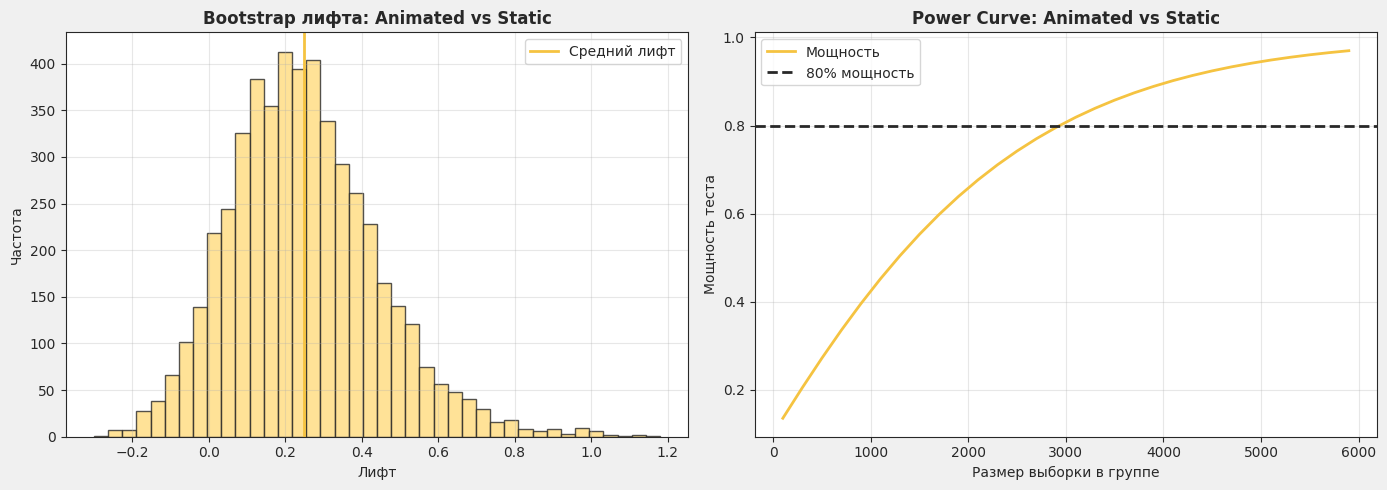


 АНАЛИЗ МОЩНОСТИ: Animated vs Static
Текущий размер выборки: Animated = 841, Static = 974
Необходимый размер выборки: 2935 на группу

Текущая мощность теста: 0.396
Целевая мощность: 0.8

Bootstrap лифт:
- средний: 24.95%
- 90% CI: -8.37%, 68.46%


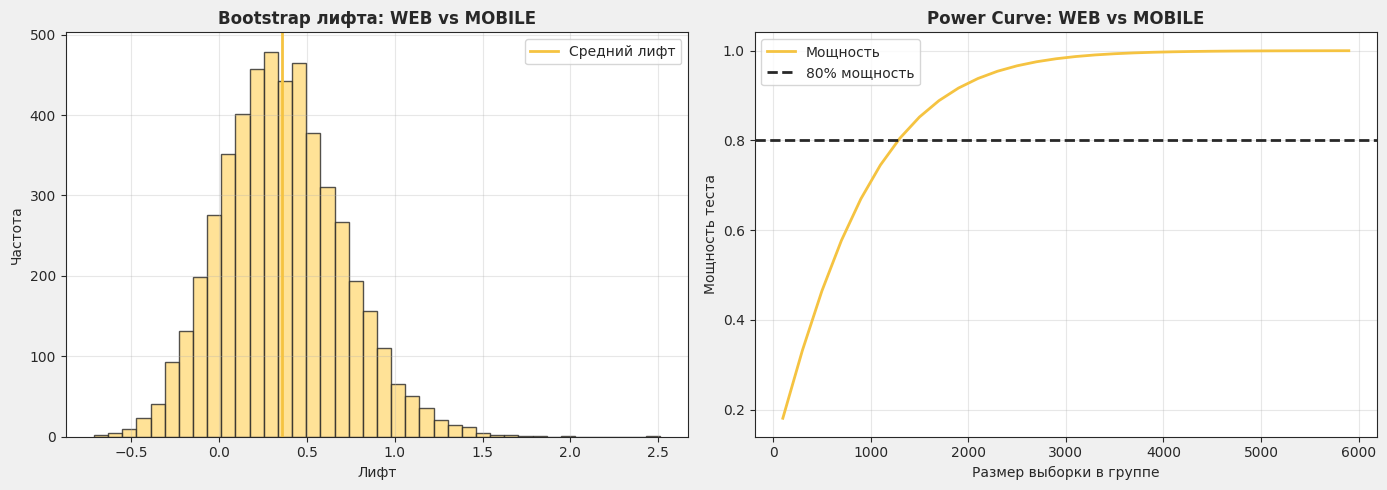


 АНАЛИЗ МОЩНОСТИ: WEB vs MOBILE
Текущий размер выборки: WEB = 132, MOBILE = 1683
Необходимый размер выборки: 1281 на группу

Текущая мощность теста: 0.292
Целевая мощность: 0.8

Bootstrap лифт:
- средний: 35.93%
- 90% CI: -26.62%, 108.16%


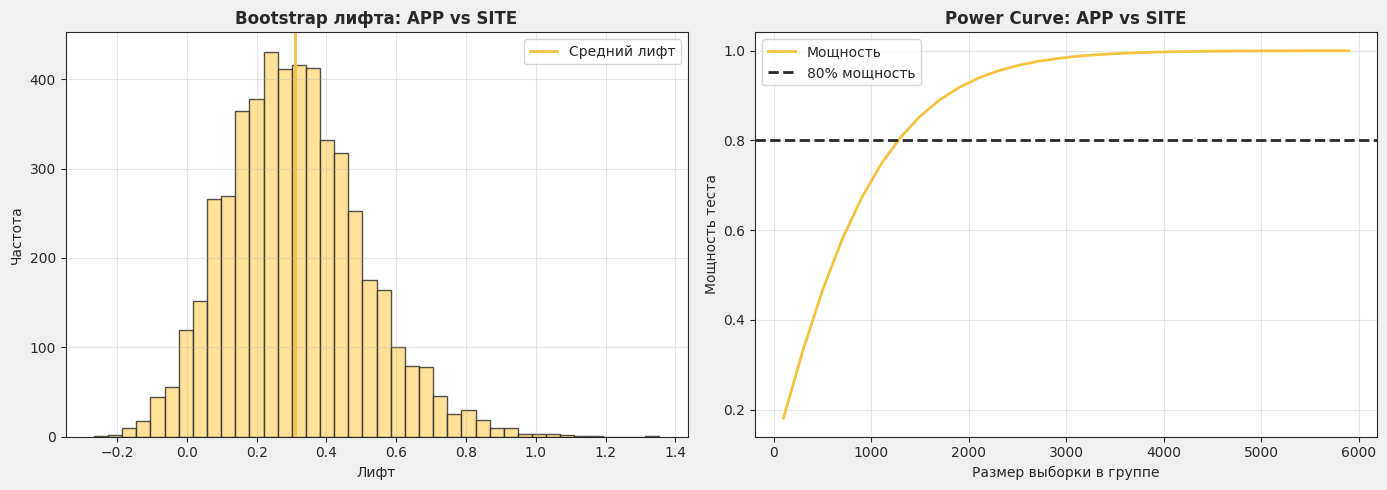


 АНАЛИЗ МОЩНОСТИ: APP vs SITE
Текущий размер выборки: APP = 679, SITE = 744
Необходимый размер выборки: 1275 на группу

Текущая мощность теста: 0.584
Целевая мощность: 0.8

Bootstrap лифт:
- средний: 31.07%
- 90% CI: -2.47%, 73.20%


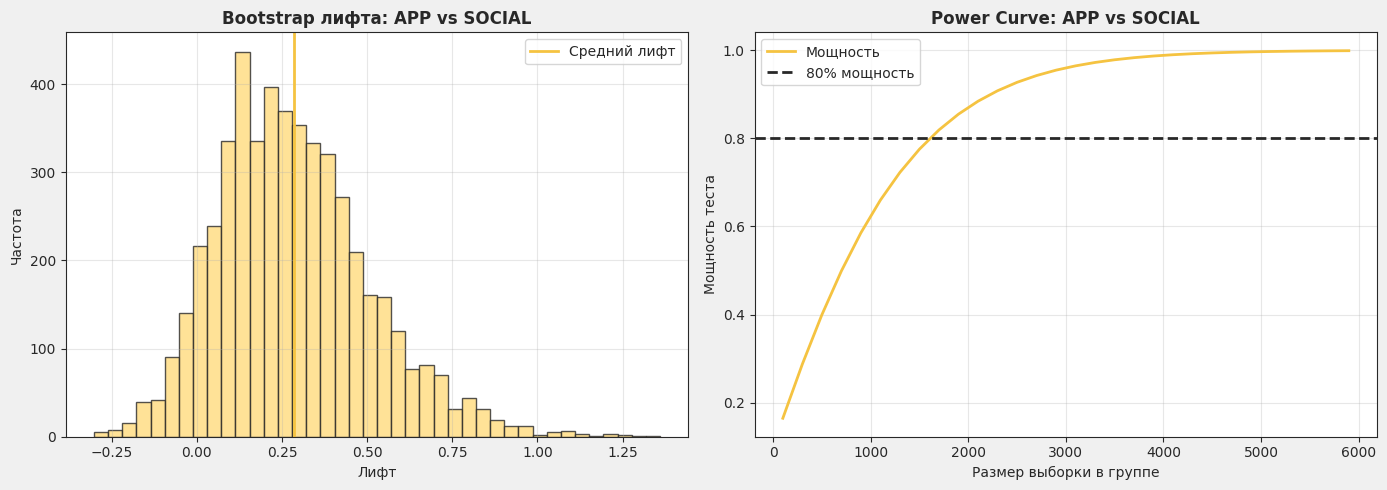


 АНАЛИЗ МОЩНОСТИ: APP vs SOCIAL
Текущий размер выборки: APP = 679, SOCIAL = 392
Необходимый размер выборки: 1608 на группу

Текущая мощность теста: 0.398
Целевая мощность: 0.8

Bootstrap лифт:
- средний: 28.39%
- 90% CI: -8.68%, 78.61%


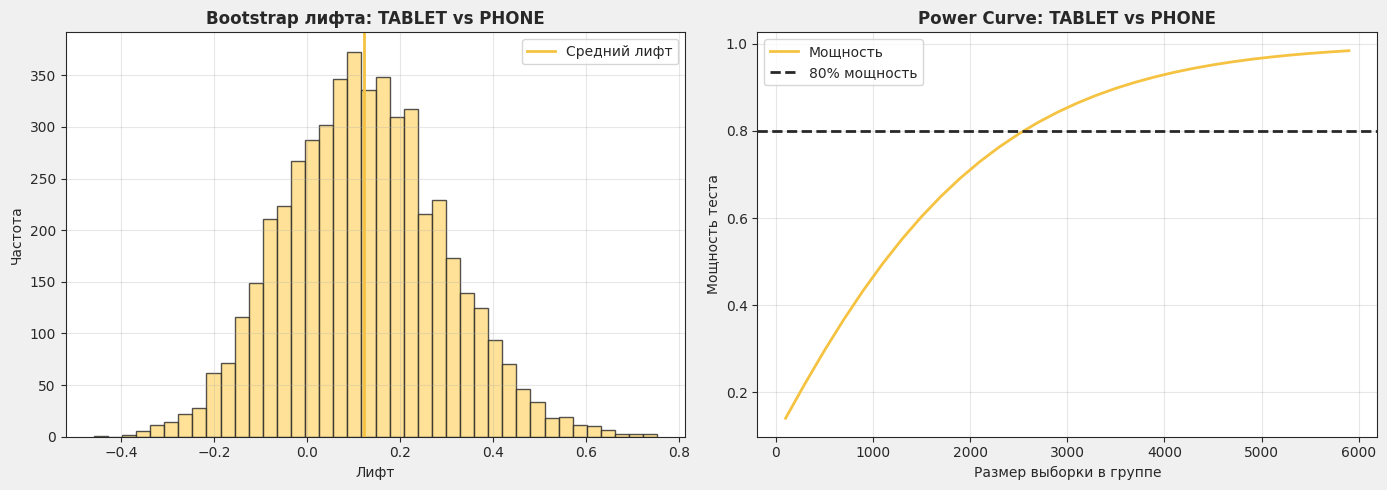


 АНАЛИЗ МОЩНОСТИ: TABLET vs PHONE
Текущий размер выборки: TABLET = 123, PHONE = 683
Необходимый размер выборки: 2552 на группу

Текущая мощность теста: 0.184
Целевая мощность: 0.8

Bootstrap лифт:
- средний: 12.37%
- 90% CI: -19.35%, 46.62%


In [20]:
analyzer = PowerAnalyzer(alpha=0.1, power_target=0.8)


# Гипотеза 1 — Animated vs Static
result_h1 = analyzer.analyze(
    succ_a=animated_clicks,
    total_a=animated_shows,
    succ_b=static_clicks,
    total_b=static_shows,
    name_a="Animated",
    name_b="Static"
)

# Гипотеза 2 — WEB vs MOBILE
result_h2 = analyzer.analyze(
    succ_a=web_clicks,
    total_a=web_shows,
    succ_b=mobile_clicks,
    total_b=mobile_shows,
    name_a="WEB",
    name_b="MOBILE"
)

# Гипотеза 3 — APP vs SITE
result_h3_site = analyzer.analyze(
    succ_a=app_switches,
    total_a=app_shows,
    succ_b=site_switches,
    total_b=site_shows,
    name_a="APP",
    name_b="SITE"
)

# Гипотеза 3 — APP vs SOCIAL
result_h3_social = analyzer.analyze(
    succ_a=app_switches,
    total_a=app_shows,
    succ_b=social_switches,
    total_b=social_shows,
    name_a="APP",
    name_b="SOCIAL"
)

# Гипотеза 4 — Tablet vs Phone
result_h4 = analyzer.analyze(
    succ_a=tablet_sw,
    total_a=tablet_regs,
    succ_b=phone_sw,
    total_b=phone_regs,
    name_a="TABLET",
    name_b="PHONE"
)


**Итоговый вывод по анализу мощности**

Анализ мощности показал, что во всех четырёх гипотезах текущего **объёма данных недостаточно**, чтобы **статистически** подтвердить наблюдаемые эффекты.

Хотя фактические лифты выглядят положительными (от +12% до +36%), тесты обладают низкой мощностью:

* мощность колеблется от **0.18 до 0.58** при требуемом уровне 0.80;
* доверительные интервалы широкие и включают **отрицательные значения**;
* bootstrap-распределения эффектов нестабильны и **не позволяют** уверенно **отделить эффект от шума**.

Для достижения требуемой мощности 80% необходимы существенно большие выборки:
для разных гипотез — от 1,200 до 3,000 наблюдений на группу, что в **2–10 раз** превышает текущие размеры выборок.

**Вывод:**

1. Неподтверждение гипотез в CDA объясняется недостатком данных, а не отсутствием эффекта.
2. Эффекты могут быть реальными, но статистических оснований для выводов сейчас нет.

**Рекомендации:**

1. Увеличить объём данных перед повторной проверкой гипотез;
2. Уделить особое внимание группам с особо низкой выборкой (WEB, TABLET, SOCIAL);
3. При возможности — провести A/B-эксперимент для прямого измерения эффекта.

### Анализируем результат

In [21]:
HYPOTHESES = [
    {
        "name": "H1_animated_vs_static",
        "pairs": [
            {
                "label": "animated_vs_static",
                "succ_a": animated_clicks,
                "total_a": animated_shows,
                "succ_b": static_clicks,
                "total_b": static_shows,
            }
        ],
        "threshold": 0.25
    },
    {
        "name": "H2_web_vs_mobile",
        "pairs": [
            {
                "label": "web_vs_mobile",
                "succ_a": web_clicks,
                "total_a": web_shows,
                "succ_b": mobile_clicks,
                "total_b": mobile_shows,
            }
        ],
        "threshold": 0.30
    },
    {
        "name": "H3_app_vs_others",
        "pairs": [
            {
                "label": "app_vs_site",
                "succ_a": app_switches,
                "total_a": app_shows,
                "succ_b": site_switches,
                "total_b": site_shows,
            },
            {
                "label": "app_vs_social",
                "succ_a": app_switches,
                "total_a": app_shows,
                "succ_b": social_switches,
                "total_b": social_shows,
            }
        ],
        "threshold": 0.25
    },
    {
        "name": "H4_tablet_vs_phone",
        "pairs": [
            {
                "label": "tablet_vs_phone",
                "succ_a": tablet_sw,
                "total_a": tablet_regs,
                "succ_b": phone_sw,
                "total_b": phone_regs,
            }
        ],
        "threshold": 0.10
    }
]

In [22]:
def run_tests_simple(hyp):
    rows = []

    comparisons = len(hyp["pairs"])

    for pair in hyp["pairs"]:
        for alpha in [0.05, 0.10]:

            evaluator = HypothesisEvaluator(alpha=alpha)
            selector = TestSelector(alpha=alpha)

            decision = selector.choose_test(
                pair["succ_a"], pair["total_a"],
                pair["succ_b"], pair["total_b"],
                comparisons=comparisons
            )

            # выбор теста
            if decision["test"] == "fisher":
                test = FisherTest()
                method = "Selector (fisher)"
            else:
                test = ZTest()
                method = "Selector (z-test + bonferroni)" if comparisons > 1 else "Selector (z-test)"

            res = evaluator.evaluate(
                test,
                pair["succ_a"], pair["total_a"],
                pair["succ_b"], pair["total_b"],
                threshold=hyp["threshold"],
                comparisons=comparisons
            )

            rows.append({
                "hypothesis": hyp["name"],
                "comparison": pair["label"],
                "alpha": round(alpha, 2),
                "method": method,
                "p_value": res["p_value_corrected"],
                "lift": res["lift"],
                "ci_low": res["ci_lift"][0] if res["ci_lift"] else None,
                "ci_high": res["ci_lift"][1] if res["ci_lift"] else None,
                "significant": res["effect_exists"]
            })

    return rows

In [23]:
rows = []
for hyp in HYPOTHESES:
    rows.extend(run_tests_simple(hyp))

df_summary = pd.DataFrame(rows)
df_summary

,hypothesis,comparison,alpha,method,p_value,lift,ci_low,ci_high,significant
0,H1_animated_vs_static,animated_vs_static,0.05,Selector (z-test),0.083503,0.234339,-0.100174,0.568852,False
1,H1_animated_vs_static,animated_vs_static,0.10,Selector (z-test),0.083503,0.234339,-0.046394,0.515071,True
2,H2_web_vs_mobile,web_vs_mobile,0.05,Selector (fisher),0.160193,0.346831,-0.208718,1.446290,False
3,H2_web_vs_mobile,web_vs_mobile,0.10,Selector (fisher),0.160193,0.346831,-0.133567,1.234108,False
4,H3_app_vs_others,app_vs_site,0.05,Selector (z-test + bonferroni),0.063415,0.298642,-0.017911,0.615194,False
5,H3_app_vs_others,app_vs_site,0.10,Selector (z-test + bonferroni),0.063415,0.298642,0.032983,0.564301,True
6,H3_app_vs_others,app_vs_social,0.05,Selector (z-test + bonferroni),0.172962,0.259606,-0.103737,0.622950,False
7,H3_app_vs_others,app_vs_social,0.10,Selector (z-test + bonferroni),0.172962,0.259606,-0.045321,0.564534,False
8,H4_tablet_vs_phone,tablet_vs_phone,0.05,Selector (z-test),0.236101,0.116605,-0.208604,0.441814,False
9,H4_tablet_vs_phone,tablet_vs_phone,0.10,Selector (z-test),0.236101,0.116605,-0.156319,0.389529,False


In [24]:
def style_results(df):

    def color_rows(row):
        if row["significant"]:
            bg = colors[1]

        else:
            if row["alpha"] == 0.05:
                bg = colors[4]
            else:
                bg = colors[3]

        return [
            f"background-color: {bg}; color: {colors[0]}"
        ] * len(row)

    return (
        df.style

        # ---------- formatting ----------
        .format({
            "alpha": "{:.2f}",
            "p_value": "{:.3f}",
            "lift": "{:.2%}",
            "ci_low": "{:.2%}",
            "ci_high": "{:.2%}"
        })

        # ---------- row coloring ----------
        .apply(color_rows, axis=1)

        # ---------- base cell style ----------
        .set_properties(**{
            "border": f"1px solid {colors[0]}",
            "text-align": "center",
            "color": colors[0]
        })

        # ---------- header ----------
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", colors[3]),
                    ("color", colors[0]),
                    ("font-weight", "bold"),
                    ("border", f"1px solid {colors[0]}")
                ]
            }
        ])
    )

In [25]:
style_results(df_summary)

,hypothesis,comparison,alpha,method,p_value,lift,ci_low,ci_high,significant
0,H1_animated_vs_static,animated_vs_static,0.05,Selector (z-test),0.084,23.43%,-10.02%,56.89%,False
1,H1_animated_vs_static,animated_vs_static,0.10,Selector (z-test),0.084,23.43%,-4.64%,51.51%,True
2,H2_web_vs_mobile,web_vs_mobile,0.05,Selector (fisher),0.160,34.68%,-20.87%,144.63%,False
3,H2_web_vs_mobile,web_vs_mobile,0.10,Selector (fisher),0.160,34.68%,-13.36%,123.41%,False
4,H3_app_vs_others,app_vs_site,0.05,Selector (z-test + bonferroni),0.063,29.86%,-1.79%,61.52%,False
5,H3_app_vs_others,app_vs_site,0.10,Selector (z-test + bonferroni),0.063,29.86%,3.30%,56.43%,True
6,H3_app_vs_others,app_vs_social,0.05,Selector (z-test + bonferroni),0.173,25.96%,-10.37%,62.29%,False
7,H3_app_vs_others,app_vs_social,0.10,Selector (z-test + bonferroni),0.173,25.96%,-4.53%,56.45%,False
8,H4_tablet_vs_phone,tablet_vs_phone,0.05,Selector (z-test),0.236,11.66%,-20.86%,44.18%,False
9,H4_tablet_vs_phone,tablet_vs_phone,0.10,Selector (z-test),0.236,11.66%,-15.63%,38.95%,False


### Анализируем утойчивость

In [26]:
class RobustnessAnalyzer:
    """
    Анализ устойчивости (robustness analysis).
    Основан на bootstrap-распределении лифта.
    """

    def __init__(self, n_boot=5000):
        self.n_boot = n_boot

        self.COLORS = {
            "text": colors[0],
            "mean": colors[1],
            "hist": colors[2],
            "threshold": colors[3],
            "zero": colors[0],
        }


    # ---------- bootstrap ----------
    def bootstrap_lift(self, succ_a, total_a, succ_b, total_b):
        p_a = succ_a / total_a
        p_b = succ_b / total_b

        lifts = []
        for _ in range(self.n_boot):
            ca = np.random.binomial(total_a, p_a)
            cb = np.random.binomial(total_b, p_b)

            ctr_a = ca / total_a
            ctr_b = cb / total_b

            lifts.append((ctr_a - ctr_b) / ctr_b)

        return np.array(lifts)

    # ---------- метрики устойчивости ----------
    def compute_metrics(self, lifts, threshold):
        ci_low, ci_high = np.percentile(lifts, [2.5, 97.5])

        return {
            "mean_lift": np.mean(lifts),
            "p_lift_positive": (lifts > 0).mean(),
            "p_lift_above_threshold": (lifts > threshold).mean(),
            "lift_std": np.std(lifts),
            "lift_iqr": np.percentile(lifts, 75) - np.percentile(lifts, 25),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "ci_width": ci_high - ci_low,
        }

    # ---------- график ----------
    def plot_lift_distribution(
      self,
      lifts,
      threshold,
      title,
      filename
    ):
      plt.figure(figsize=(7, 4))

      # --- распределение ---
      plt.hist(
          lifts,
          bins=40,
          color=self.COLORS["hist"],
          edgecolor=self.COLORS["text"],
          alpha=0.85
      )

      plt.axvline(
          0,
          color=self.COLORS["zero"],
          linestyle="--",
          linewidth=2,
          label="Lift = 0"
      )

      plt.axvline(
          threshold,
          color=self.COLORS["zero"],
          linestyle="--",
          linewidth=2.5,
          alpha=0.6,
          label="Business threshold"
      )

      plt.axvline(
          np.mean(lifts),
          color=self.COLORS["mean"],
          linestyle="--",
          linewidth=3,
          label="Mean lift"
      )

      plt.title(title, fontweight="bold")
      plt.xlabel("Lift")
      plt.ylabel("Frequency")
      plt.grid(True, alpha=0.3)
      plt.legend()

      plt.tight_layout()

      os.makedirs(graph_path, exist_ok=True)
      filepath = os.path.join(graph_path, filename)

      plt.savefig(
          filepath,
          dpi=150,
          bbox_inches="tight",
          facecolor=plt.gcf().get_facecolor()
      )
      plt.show()

    # ---------- анализ метрик ----------
    def analyze(
        self,
        succ_a,
        total_a,
        succ_b,
        total_b,
        threshold,
        name_a="A",
        name_b="B"
    ):
        lifts = self.bootstrap_lift(
            succ_a, total_a,
            succ_b, total_b
        )

        metrics = self.compute_metrics(lifts, threshold)

        title = f"Robustness: {name_a} vs {name_b}"
        filename = f"robustness_{name_a}_vs_{name_b}".lower().replace(" ", "_") + ".png"

        self.plot_lift_distribution(
            lifts,
            threshold,
            title=title,
            filename=filename
        )

        # ===== Текстовый вывод =====
        print("\n==============================")
        print(f" ROBUSTNESS ANALYSIS: {name_a} vs {name_b}")
        print("==============================")

        print(f"Mean lift: {metrics['mean_lift'] * 100:.2f}%")
        print(f"P(lift > 0): {metrics['p_lift_positive']:.3f}")
        print(f"P(lift > threshold): {metrics['p_lift_above_threshold']:.3f}")
        print(f"Lift std: {metrics['lift_std']:.3f}")
        print(f"Lift IQR: {metrics['lift_iqr']:.3f}")
        print(
            f"90% CI: "
            f"{metrics['ci_low'] * 100:.2f}% — "
            f"{metrics['ci_high'] * 100:.2f}%"
        )

        return metrics

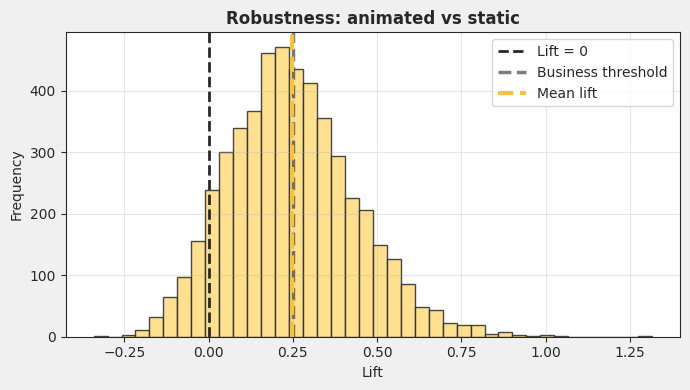


 ROBUSTNESS ANALYSIS: animated vs static
Mean lift: 24.77%
P(lift > 0): 0.918
P(lift > threshold): 0.470
Lift std: 0.188
Lift IQR: 0.249
90% CI: -8.64% — 65.21%


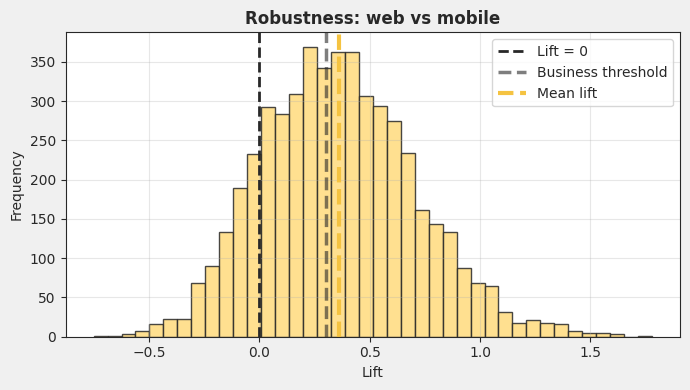


 ROBUSTNESS ANALYSIS: web vs mobile
Mean lift: 36.02%
P(lift > 0): 0.848
P(lift > threshold): 0.549
Lift std: 0.349
Lift IQR: 0.470
90% CI: -25.55% — 108.19%


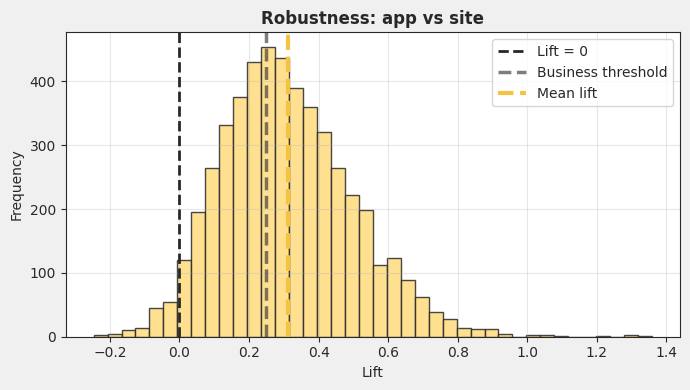


 ROBUSTNESS ANALYSIS: app vs site
Mean lift: 31.07%
P(lift > 0): 0.970
P(lift > threshold): 0.597
Lift std: 0.189
Lift IQR: 0.249
90% CI: -1.12% — 71.21%


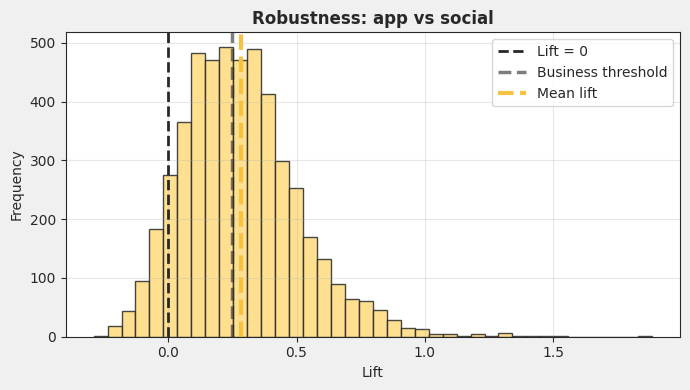


 ROBUSTNESS ANALYSIS: app vs social
Mean lift: 28.29%
P(lift > 0): 0.911
P(lift > threshold): 0.520
Lift std: 0.229
Lift IQR: 0.285
90% CI: -9.28% — 81.44%


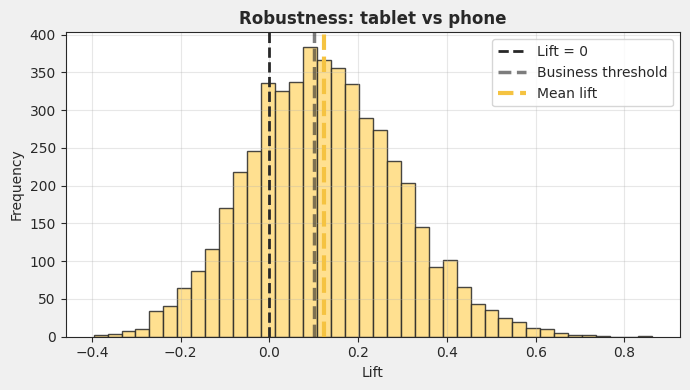


 ROBUSTNESS ANALYSIS: tablet vs phone
Mean lift: 12.33%
P(lift > 0): 0.763
P(lift > threshold): 0.536
Lift std: 0.169
Lift IQR: 0.227
90% CI: -19.19% — 47.45%


,hypothesis,comparison,threshold,mean_lift,p_lift_positive,p_lift_above_threshold,lift_std,lift_iqr,ci_low,ci_high,ci_width
0,H1_animated_vs_static,animated_vs_static,0.25,0.247680,0.9180,0.4698,0.187786,0.248506,-0.086371,0.652060,0.738431
1,H2_web_vs_mobile,web_vs_mobile,0.30,0.360207,0.8484,0.5490,0.349132,0.470343,-0.255474,1.081887,1.337361
2,H3_app_vs_others,app_vs_site,0.25,0.310710,0.9700,0.5972,0.188587,0.249423,-0.011179,0.712077,0.723255
3,H3_app_vs_others,app_vs_social,0.25,0.282888,0.9110,0.5198,0.228733,0.285093,-0.092784,0.814433,0.907216
4,H4_tablet_vs_phone,tablet_vs_phone,0.10,0.123269,0.7632,0.5364,0.168831,0.227131,-0.191851,0.474534,0.666386


In [27]:
robust_rows = []
robust = RobustnessAnalyzer(n_boot=5000)

for hyp in HYPOTHESES:
    for pair in hyp["pairs"]:

        metrics = robust.analyze(
            succ_a=pair["succ_a"],
            total_a=pair["total_a"],
            succ_b=pair["succ_b"],
            total_b=pair["total_b"],
            threshold=hyp["threshold"],
            name_a=pair["label"].split("_vs_")[0],
            name_b=pair["label"].split("_vs_")[1],
        )

        robust_rows.append({
            "hypothesis": hyp["name"],
            "comparison": pair["label"],
            "threshold": hyp["threshold"],
            **metrics
        })

df_robustness = pd.DataFrame(robust_rows)
df_robustness

In [28]:
def style_robustness_results(df):

    # --- цветовые карты ---
    business_cmap = LinearSegmentedColormap.from_list(
        "business",
        [colors[4], colors[2], colors[1]]  # white → light yellow → yellow
    )

    stability_cmap = LinearSegmentedColormap.from_list(
        "stability",
        [colors[4], colors[2]]
    )

    risk_cmap = LinearSegmentedColormap.from_list(
        "risk",
        [colors[4], colors[3]]
    )

    return (
        df.style
        # ---------- формат ----------
        .format({
            "mean_lift": "{:.2%}",
            "p_lift_positive": "{:.2f}",
            "p_lift_above_threshold": "{:.2f}",
            "ci_width": "{:.2f}",
            "lift_std": "{:.2f}",
            "threshold": "{:.2f}",
            "ci_low": "{:.2%}",
            "ci_high": "{:.2%}",
        })

        # ---------- BUSINESS ----------
        .background_gradient(
            subset=["p_lift_above_threshold"],
            cmap=business_cmap
        )

        # ---------- STABILITY ----------
        .background_gradient(
            subset=["p_lift_positive"],
            cmap=stability_cmap
        )

        # ---------- RISK ----------
        .background_gradient(
            subset=["ci_width", "lift_std"],
            cmap=risk_cmap
        )

        # ---------- базовый стиль ----------
        .set_properties(**{
            "border": f"1px solid {colors[0]}",
            "text-align": "center",
            "color": colors[0]
        })

        # ---------- заголовки ----------
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", colors[3]),
                    ("color", colors[0]),
                    ("font-weight", "bold"),
                    ("border", f"1px solid {colors[0]}")
                ]
            }
        ])
    )


In [30]:
style_robustness_results(df_robustness)

,hypothesis,comparison,threshold,mean_lift,p_lift_positive,p_lift_above_threshold,lift_std,lift_iqr,ci_low,ci_high,ci_width
0,H1_animated_vs_static,animated_vs_static,0.25,24.77%,0.92,0.47,0.19,0.248506,-8.64%,65.21%,0.74
1,H2_web_vs_mobile,web_vs_mobile,0.30,36.02%,0.85,0.55,0.35,0.470343,-25.55%,108.19%,1.34
2,H3_app_vs_others,app_vs_site,0.25,31.07%,0.97,0.60,0.19,0.249423,-1.12%,71.21%,0.72
3,H3_app_vs_others,app_vs_social,0.25,28.29%,0.91,0.52,0.23,0.285093,-9.28%,81.44%,0.91
4,H4_tablet_vs_phone,tablet_vs_phone,0.10,12.33%,0.76,0.54,0.17,0.227131,-19.19%,47.45%,0.67


*p_lift_above_threshold* - Вероятность того, что эффект достигает бизнес-порога

*p_lift_positive* - Вероятность того, что эффект вообще положительный

*mean_lift* - Средний эффект по бутстрэпу

*ci_low, ci_high, ci_width* - Насколько широко “размазан” эффект



**Вывод:**
Анализ устойчивости показывает, что во всех гипотезах **эффект** *чаще положителен,*
однако **вероятность** достижения бизнес-порога *не превышает 61%.*

Это указывает на высокую вариативность эффекта и недостаточную надёжность
для принятия продуктовых решений без дополнительного тестирования
после увеличения выборки.

Наиболее перспективной является гипотеза **app vs site.**

На текущем этапе применение ML-подходов нецелесообразно, поскольку bootstrap-анализ показывает высокую вариативность эффекта и отсутствие устойчивого бизнес-uplift. В условиях слабого и нестабильного сигнала ML-модели с высокой вероятностью будут переобучаться и не дадут дополнительной ценности по сравнению с классическими статистическими методами.